# Supervised Learning (Classification): Credit Risk Scoring for KUR BRI
## Introduction to Data Science for Economists

**Case Study:** Credit Risk Scoring for Kredit Usaha Rakyat (KUR) — Bank Rakyat Indonesia (BRI)

### Learning objectives
1. Explain regression vs classification.
2. Understand major classification algorithms.
3. Explain the mathematical intuition behind Logistic Regression, SVM, Decision Trees, and Random Forests.
4. Distinguish Linear Regression from Logistic Regression.
5. Explain SVM for regression (SVR) versus classification (SVC).
6. Compare Decision Trees and Random Forests.
7. Build a simple credit-risk classifier.
8. Evaluate it with Confusion Matrix, Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
9. Interpret results from an economics/banking perspective.
10. Connect borrower-level risk to a simple portfolio stress indicator.

> **Important:** Public borrower-level KUR BRI default data are not used here. This notebook uses a public credit-risk dataset as a **teaching proxy**, not proprietary BRI/KUR data.


## 0. Real-World Context: KUR BRI

KUR is financing for productive and feasible businesses. BRI's official information describes KUR as a financing program for productive businesses that may not have sufficient additional collateral.

Credit-risk scoring is a useful Data Science application:

> **Can information available about a borrower be used to classify whether the borrower is likely to default?**

A Machine Learning model is a **decision-support tool**, not a replacement for a bank's credit policy.


## 1. Regression vs Classification

### Regression
Predicts a continuous numerical value.

Examples: loan loss amount, sales, income, loan amount.

$$
\hat{y}=\beta_0+\beta_1x_1+\cdots+\beta_px_p
$$

### Classification
Predicts a category.

For credit risk:

$$
Y=
\begin{cases}
1 & \text{Default / High Risk}\\
0 & \text{Non-default / Lower Risk}
\end{cases}
$$

**Key question:** Are we predicting a number or a category?


### Why not simply use Linear Regression for default?

If the target is 0/1, Linear Regression can produce values such as:

$$
-0.25,\quad 0.42,\quad 1.18
$$

These are awkward as probabilities. Logistic Regression transforms a linear score into a value between 0 and 1.


## 2. Algorithms in Classification

This notebook compares four classifiers:

1. **Logistic Regression**
2. **Support Vector Machine (SVM)**
3. **Decision Tree**
4. **Random Forest**

Other classifiers include KNN, Naive Bayes, Gradient Boosting, and Neural Networks.

The course reference also discusses Logistic Regression, SVM, Decision Trees, Random Forests, and other supervised-learning methods in economics and finance.


## 3. Mathematical Formula — Logistic Regression

First calculate a linear score:

$$
z=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p
$$

Then use the sigmoid function:

$$
P(Y=1\mid X)=\frac{1}{1+e^{-z}}
$$

A common threshold is:

$$
\hat y=
\begin{cases}
1 & \text{if }P(Y=1\mid X)\geq0.5\\
0 & \text{if }P(Y=1\mid X)<0.5
\end{cases}
$$

For credit risk, the output can be interpreted as a **predicted probability of default**.


## 4. Linear Regression vs Logistic Regression

| Feature | Linear Regression | Logistic Regression |
|---|---|---|
| Main task | Regression | Classification |
| Target | Continuous number | Class / probability |
| Output | Any real number | 0–1 probability |
| Example | Predict loan loss amount | Predict probability of default |
| Evaluation | MAE, RMSE, R² | Confusion Matrix, Accuracy, Precision, Recall, F1, ROC-AUC |

**Simple analogy**

Linear Regression: *How much?*

Logistic Regression: *Which class / how likely?*


## 5. Mathematical Formula — SVM: Classification vs Regression

### SVM Classification (SVC)

A linear decision boundary can be written as:

$$
w^Tx+b=0
$$

The classifier predicts using the side of the boundary:

$$
\hat y=\operatorname{sign}(w^Tx+b)
$$

A simplified hard-margin objective is:

$$
\min_{w,b}\frac{1}{2}\lVert w\rVert^2
$$

subject to:

$$
y_i(w^Tx_i+b)\geq1
$$

The objective is to find a separating boundary with a large margin.

### SVM Regression (SVR)

SVR predicts a continuous value:

$$
f(x)=w^Tx+b
$$

and allows errors within an epsilon-tube. Observations outside the tolerance are penalized:

$$
|y_i-f(x_i)|>\epsilon
$$

**SVC → classifies. SVR → predicts a number.**


## 6. Mathematical Formula — Decision Tree

A classification tree repeatedly splits observations using rules.

A common impurity measure is **Gini impurity**:

$$
Gini=1-\sum_{k=1}^{K}p_k^2
$$

For binary credit risk:

$$
Gini=1-p_{default}^2-p_{nondefault}^2
$$

A useful split tends to create child nodes that are more homogeneous.

**Intuition:** the tree asks a sequence of if–then questions until it reaches a prediction.


## 7. Mathematical Formula — Random Forest

Random Forest combines many Decision Trees.

For classification:

$$
\hat y=
\operatorname{mode}
\left(T_1(x),T_2(x),\ldots,T_B(x)\right)
$$

where $T_b(x)$ is the prediction from tree $b$ and $B$ is the number of trees.

**Intuition:** instead of trusting one tree, ask many trees and combine their predictions.


## 8. Why Compare Several Classification Algorithms?

There is no universal best classifier.

For credit risk, compare:

- Predictive performance
- Interpretability
- Stability
- Computational complexity
- Cost of false positives and false negatives
- Fairness and regulatory requirements

The course reference emphasizes comparing algorithms and considering interpretability when predictive performance is similar.


# 9. Dataset Specification

## Recommended dataset: Kaggle Credit Risk Dataset

Source:
https://www.kaggle.com/datasets/laotse/credit-risk-dataset

The dataset contains credit-risk variables such as:

- `person_age`
- `person_income`
- `person_home_ownership`
- `person_emp_length`
- `loan_intent`
- `loan_grade`
- `loan_amnt`
- `loan_int_rate`
- `loan_status`
- `loan_percent_income`
- `cb_person_default_on_file`
- `cb_preson_cred_hist_length`

`loan_status` is the binary target: 0 = non-default, 1 = default.

### Why this dataset?
It is public, beginner-friendly, and has an explicit default target.

### Important limitation
It is **not BRI's internal KUR data**. We use it to simulate a KUR-style credit-risk problem.

### Other options
- Home Credit Default Risk (Kaggle)
- Loan Default Prediction (Kaggle)
- YBI Foundation Credit Default.csv (GitHub)


In [1]:
# Install KaggleHub so Google Colab can download the dataset.
!pip -q install kagglehub

# Import pandas for tabular data.
import pandas as pd

# Import numpy for numerical operations.
import numpy as np

# Import matplotlib for charts.
import matplotlib.pyplot as plt

# Import seaborn for statistical visualization.
import seaborn as sns

# Import KaggleHub for downloading the public dataset.
import kagglehub

# Import Path for locating the downloaded file.
from pathlib import Path


In [2]:
# Download the public credit-risk dataset from Kaggle.
dataset_path = kagglehub.dataset_download("laotse/credit-risk-dataset")

# Show the download location.
print("Dataset folder:", dataset_path)

# Show files in the downloaded folder.
print(list(Path(dataset_path).glob("*")))


Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Dataset folder: /kaggle/input/credit-risk-dataset
[PosixPath('/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv')]


In [3]:
# Find CSV files in the downloaded dataset.
csv_files = list(Path(dataset_path).glob("*.csv"))

# Use the first CSV file.
file_path = csv_files[0]

# Load the dataset.
df = pd.read_csv(file_path)

# Display the first five rows.
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Display the number of observations and variables.
print("Shape:", df.shape)

# Display all column names.
print("\nColumns:")
print(df.columns.tolist())

# Display data types and missing-value counts.
print("\nData information:")
df.info()


Shape: (32581, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 

# 10. Data Understanding

Before classification, check:

- Missing values
- Duplicate observations
- Target balance
- Numerical variables
- Categorical variables
- Potential outliers

> **Understand the data before building the model.**


In [5]:
# Count missing values by column.
missing_values = df.isnull().sum()

# Display only columns with missing values.
missing_values[missing_values > 0].sort_values(ascending=False)


,0
loan_int_rate,3116
person_emp_length,895


In [6]:
# Count duplicated rows.
duplicate_count = df.duplicated().sum()

# Display the number of duplicates.
print("Duplicated rows:", duplicate_count)


Duplicated rows: 165


In [7]:
# Count observations in each target class.
print(df["loan_status"].value_counts())

# Display target percentages.
print("\nTarget percentages:")
print(df["loan_status"].value_counts(normalize=True).mul(100).round(2))


loan_status
0    25473
1     7108
Name: count, dtype: int64

Target percentages:
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64


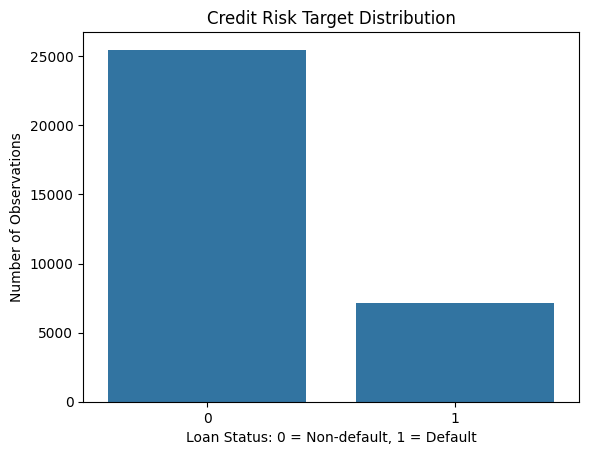

In [8]:
# Plot the target distribution.
sns.countplot(data=df, x="loan_status")

# Add a title.
plt.title("Credit Risk Target Distribution")

# Label the x-axis.
plt.xlabel("Loan Status: 0 = Non-default, 1 = Default")

# Label the y-axis.
plt.ylabel("Number of Observations")

# Display the chart.
plt.show()


# 11. Feature Selection for the Classroom Model

### Numerical features
- `person_age`
- `person_income`
- `person_emp_length`
- `loan_amnt`
- `loan_int_rate`
- `loan_percent_income`
- `cb_preson_cred_hist_length`

### Categorical features
- `person_home_ownership`
- `loan_intent`
- `loan_grade`
- `cb_person_default_on_file`

### Target
- `loan_status`

These features have intuitive economic meanings: income, employment, loan size, interest rate, debt burden, housing, loan purpose, and credit history.


In [9]:
# Define the numerical variables.
numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

# Define the categorical variables.
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

# Define the target.
target = "loan_status"

# Keep only the selected columns.
model_df = df[numeric_features + categorical_features + [target]].copy()

# Remove missing observations in these selected columns.
model_df = model_df.dropna()

# Display the modeling dataset size.
print("Modeling data shape:", model_df.shape)

Modeling data shape: (28638, 12)


# 12. Train-Test Split

We use:

- **Training set:** learn model parameters.
- **Test set:** evaluate unseen observations.

We use stratification to preserve the approximate target-class proportion.

> The test set should not be used for model tuning.


In [10]:
# Import train_test_split.
from sklearn.model_selection import train_test_split

# Separate predictors.
X = model_df.drop(columns=[target])

# Separate target.
y = model_df[target]

# Split into 80% training and 20% test data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes.
print("Training observations:", len(X_train))
print("Test observations:", len(X_test))


Training observations: 22910
Test observations: 5728


# 13. Preprocessing

Numerical variables are standardized:

$$
z=\frac{x-\mu}{\sigma}
$$

Categorical variables are one-hot encoded.

The preprocessing is placed inside a Pipeline so that transformations are learned from training data and applied consistently to test data.


In [11]:
# Import preprocessing tools.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Create the numerical preprocessing pipeline.
numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

# Create the categorical preprocessing pipeline.
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

# Combine numerical and categorical preprocessing.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# 14. Model 1 — Logistic Regression

Logistic Regression estimates:

$$
P(Y=1\mid X)=\frac{1}{1+e^{-z}}
$$

with:

$$
z=\beta_0+\beta_1x_1+\cdots+\beta_px_p
$$

It is a useful and relatively interpretable baseline for credit-risk classification.


In [12]:
# Import Logistic Regression.
from sklearn.linear_model import LogisticRegression

# Build the Logistic Regression pipeline.
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Train the model.
logistic_model.fit(X_train, y_train)

# Predict classes.
logistic_pred = logistic_model.predict(X_test)

# Predict default probabilities.
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]


# 15. Model 2 — Support Vector Machine (SVM)

We use an RBF-kernel **SVC**.

The RBF kernel allows the classifier to learn nonlinear decision boundaries.

SVM is especially useful for teaching the distinction:

- **SVC → classification**
- **SVR → regression**


In [13]:
# Import Support Vector Classifier.
from sklearn.svm import SVC

# Build the SVM classification pipeline.
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]
)

# Train the SVM.
svm_model.fit(X_train, y_train)

# Predict classes.
svm_pred = svm_model.predict(X_test)

# Predict default probabilities.
svm_prob = svm_model.predict_proba(X_test)[:, 1]


# 16. Model 3 — Decision Tree

A Decision Tree learns a sequence of rules.

Example:

> If loan-to-income is high → follow one branch.

> If income is low → follow another branch.

The final leaf gives the predicted class.

Trees can capture nonlinear relationships but a single tree can overfit.


In [14]:
# Import DecisionTreeClassifier.
from sklearn.tree import DecisionTreeClassifier

# Build the Decision Tree pipeline.
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Train the tree.
tree_model.fit(X_train, y_train)

# Predict classes.
tree_pred = tree_model.predict(X_test)

# Predict default probabilities.
tree_prob = tree_model.predict_proba(X_test)[:, 1]


# 17. Model 4 — Random Forest

Random Forest combines many Decision Trees.

$$
\hat y=
\operatorname{mode}
(T_1(x),T_2(x),\ldots,T_B(x))
$$

The ensemble approach can make predictions more robust than a single tree.


In [15]:
# Import RandomForestClassifier.
from sklearn.ensemble import RandomForestClassifier

# Build the Random Forest pipeline.
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the Random Forest.
rf_model.fit(X_train, y_train)

# Predict classes.
rf_pred = rf_model.predict(X_test)

# Predict default probabilities.
rf_prob = rf_model.predict_proba(X_test)[:, 1]


# 18. Classification Evaluation

For classification we evaluate:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

The goal is not only to ask **"How many predictions are correct?"** but also **"What kinds of mistakes does the model make?"**


In [16]:
# Import classification metrics.
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Store predictions and probabilities for each model.
results = {
    "Logistic Regression": (logistic_pred, logistic_prob),
    "SVM": (svm_pred, svm_prob),
    "Decision Tree": (tree_pred, tree_prob),
    "Random Forest": (rf_pred, rf_prob)
}

# Create an empty list for metrics.
metrics_list = []

# Calculate metrics for every model.
for name, (pred, prob) in results.items():
    metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

# Convert metrics to a DataFrame.
metrics_df = pd.DataFrame(metrics_list)

# Sort by F1-Score.
metrics_df.sort_values("F1-Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Random Forest,0.896823,0.769934,0.746978,0.758282,0.920693
1,SVM,0.910789,0.947304,0.622885,0.751580,0.891359
2,Decision Tree,0.888966,0.753138,0.725222,0.738916,0.877937
0,Logistic Regression,0.859986,0.752589,0.526994,0.619905,0.861684


# 19. Confusion Matrix

| | Predicted Non-default | Predicted Default |
|---|---:|---:|
| **Actual Non-default** | TN | FP |
| **Actual Default** | FN | TP |

### Credit-risk interpretation

- **TP:** correctly identifies a defaulter.
- **TN:** correctly identifies a non-defaulter.
- **FP:** flags a borrower as default risk when they do not default.
- **FN:** misses a borrower who actually defaults.

The economic costs of FP and FN may be different.


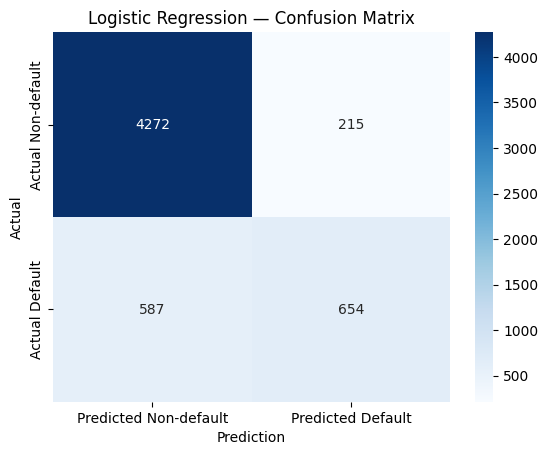

In [17]:
# Create the Logistic Regression confusion matrix.
cm = confusion_matrix(y_test, logistic_pred)

# Plot the confusion matrix.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-default", "Predicted Default"],
    yticklabels=["Actual Non-default", "Actual Default"]
)

# Add title and axis labels.
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")

# Display the chart.
plt.show()


# 20. Mathematical Formula — Classification Metrics

### Accuracy

$$
Accuracy=
\frac{TP+TN}{TP+TN+FP+FN}
$$

### Precision

$$
Precision=
\frac{TP}{TP+FP}
$$

### Recall

$$
Recall=
\frac{TP}{TP+FN}
$$

### F1-Score

$$
F1=
2\times
\frac{Precision\times Recall}
{Precision+Recall}
$$

For credit risk, Recall can be especially important when missing a true defaulter is costly. But the appropriate metric depends on the bank's economic loss structure.


# 21. Compare All Four Models

Do not automatically choose the model with the highest Accuracy.

For credit risk, compare:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Interpretability
- Cost of FP and FN

The "best" model depends on the decision objective.


In [18]:
# Display the complete model comparison table.
metrics_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.896823,0.769934,0.746978,0.758282,0.920693
1,SVM,0.910789,0.947304,0.622885,0.751580,0.891359
2,Decision Tree,0.888966,0.753138,0.725222,0.738916,0.877937
3,Logistic Regression,0.859986,0.752589,0.526994,0.619905,0.861684


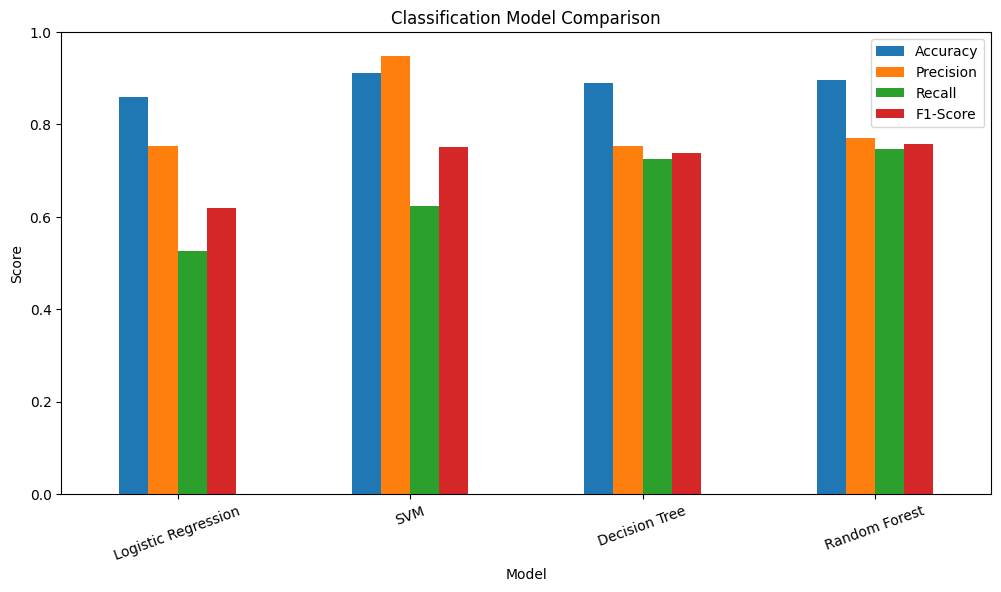

In [19]:
# Select the main classification metrics for plotting.
plot_df = metrics_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]]

# Plot the model comparison.
plot_df.plot(kind="bar", figsize=(12, 6))

# Add labels.
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

# Display the chart.
plt.show()


# 22. Application — Credit Scoring for KUR BRI

A simplified workflow is:

$$
\text{Applicant Data}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Classification Model}
\rightarrow
P(\text{Default})
\rightarrow
\text{Risk Category}
$$

For illustration only, we can use:

- Low Risk: probability < 0.30
- Medium Risk: 0.30–0.60
- High Risk: > 0.60

> These thresholds are **classroom examples**, not BRI's actual credit policy or KUR eligibility rules.


In [20]:
# Use Random Forest predicted default probabilities as an illustrative score.
risk_score = rf_prob

# Convert probability into illustrative risk categories.
risk_category = pd.cut(
    risk_score,
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Create a DataFrame for interpretation.
risk_results = pd.DataFrame({
    "Actual_Default": y_test.values,
    "Predicted_Default_Probability": risk_score,
    "Risk_Category": risk_category
})

# Display the first ten observations.
risk_results.head(10)


,Actual_Default,Predicted_Default_Probability,Risk_Category
0,0,0.304436,Medium Risk
1,0,0.049271,Low Risk
2,0,0.670260,High Risk
3,0,0.108434,Low Risk
4,0,0.107888,Low Risk
5,0,0.182503,Low Risk
6,0,0.475428,Medium Risk
7,0,0.147426,Low Risk
8,0,0.185508,Low Risk
9,0,0.171443,Low Risk


# 23. From Credit Risk to Portfolio Stress / Crisis Monitoring

A bank can aggregate borrower-level predictions.

A simple classroom indicator is:

$$
HighRiskRate=
\frac{\text{Number of High-Risk Borrowers}}
{\text{Total Borrowers}}
$$

If the high-risk share rises substantially, this can be interpreted as a **portfolio stress signal**.

However, this is **not a formal macroeconomic crisis-prediction model**.

A real crisis model would need additional time-series or macro-financial variables such as GDP growth, unemployment, inflation, interest rates, exchange rates, credit growth, and NPL ratios.


In [21]:
# Calculate the illustrative high-risk rate.
high_risk_rate = (risk_results["Risk_Category"] == "High Risk").mean()

# Display the rate.
print(f"Baseline High-Risk Rate: {high_risk_rate:.2%}")


Baseline High-Risk Rate: 17.84%


# 24. Stress Scenario Simulation

We can simulate a hypothetical deterioration in credit risk.

This is a **scenario analysis**, not a prediction of an actual economic crisis.

Suppose predicted default probabilities increase by 10 percentage points:

$$
p_{stress}=\min(p+0.10,1)
$$

Then we can observe how the High-Risk Rate changes.


In [22]:
# Increase predicted default probability by 10 percentage points.
stress_probability = np.clip(risk_score + 0.10, 0, 1)

# Convert stressed probabilities into risk categories.
stress_category = pd.cut(
    stress_probability,
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Calculate the stressed high-risk rate.
stress_high_risk_rate = (stress_category == "High Risk").mean()

# Display baseline and stress results.
print(f"Baseline High-Risk Rate: {high_risk_rate:.2%}")
print(f"Stress High-Risk Rate:   {stress_high_risk_rate:.2%}")


Baseline High-Risk Rate: 17.84%
Stress High-Risk Rate:   21.02%


# 25. Economic Interpretation

Do not stop at:

> "Random Forest has the highest F1-Score."

Ask:

1. What does the model predict?
2. Which borrower characteristics are associated with the prediction?
3. What are the costs of false positives and false negatives?
4. Is the model sufficiently interpretable?
5. What could happen to portfolio risk during an economic downturn?
6. Is the dataset representative of the population we want to make decisions about?

### Key economic lesson

> **Machine Learning provides a predictive tool; economists still need to interpret incentives, risks, costs, institutions, and economic context.**


# 26. Student Exercise

### Exercise 1 — The Different Validation between Regression and Classification
Why do classification algorithms use Confusion Matrix for validation method (Accuracy, Recall, Precision, F1-Score, ROC-AUC)? And why do regression algorithms use MAE, RMSE, $R^2$? They are both Supervised Learning, but why do they use different validation method?

### Exercise 2 — Model Comparison
Compare Logistic Regression, SVM, Decision Tree, and Random Forest.

Answer:
1. Which model has the highest Accuracy?
2. Which has the highest Recall?
3. Which has the highest Precision?
4. Which has the highest F1-Score?
5. Which has the highest ROC-AUC?
6. Is the highest-Accuracy model necessarily the best credit-risk model?

### Exercise 3 — Economic Decision
Choose one model for a KUR-style credit-risk screening system. Justify your choice using predictive performance, interpretability, and the costs of FP/FN.

### Exercise 4 — The Best Machine Learning Model
From those Classification model comparison, which one is the best model? And why?

### Exercise 5 - Machine Learning Model and Bank Policy
From the dataset, which borrower groups appear to have lower or higher credit risk? How do you find it out? Would you automatically consider the low-risk groups eligible for KUR? Explain why or why not.

# 27. Important Caveats

This notebook is a teaching implementation.

It is **not**:
- an actual BRI credit-scoring system;
- an official KUR approval model;
- a substitute for BRI/OJK credit-risk policy;
- evidence that a borrower should or should not receive credit;
- a causal model of default.

A real credit-scoring system would require appropriate borrower data governance, validation, monitoring, explainability, fairness assessment, regulatory compliance, and careful protection against data leakage.


# References & Data Sources

### Public dataset
Kaggle — Credit Risk Dataset  
https://www.kaggle.com/datasets/laotse/credit-risk-dataset

Kaggle — Home Credit Default Risk  
https://www.kaggle.com/c/home-credit-default-risk/data

Kaggle — Loan Default Prediction  
https://www.kaggle.com/competitions/loan-default-pred/data

YBI Foundation — Credit Default Dataset  
https://github.com/YBIFoundation/Dataset/blob/main/Credit%20Default.csv

### BRI / KUR context
Bank BRI — KUR  
https://bri.co.id/web/guest/kur

Bank BRI — KUR Kecil  
https://bri.co.id/web/guest/id/kur-kecil

### Course reference
Alecssi, L. & Savona, R. — *Machine Learning for Financial Stability*, in *Data Science for Economics and Finance: Methodologies and Applications*.


# Final Summary

> **Regression predicts "how much." Classification predicts "which class."**

For KUR-style credit risk:

$$
\text{Borrower Characteristics}
\rightarrow
\text{Default Probability}
\rightarrow
\text{Risk Classification}
$$

The goal is not simply to build a model with a high score. The goal is to understand **what the model predicts, how reliable it is, what mistakes it makes, and what those mistakes mean economically.**
